# Metal Visualization: BFS vs DFS Eye-Tracking Analysis

---

**Scope:** Metal visualization style only (`DE-bft.wmv` / `DE-dft.wmv` columns from Metal XLS exports).  
**Question:** Within the Metal style, does the algorithm being animated (BFS vs DFS) change *how* viewers allocate attention between pseudocode and the geospatial map?  
---

### Metrics extracted per participant

| Column | Meaning |
|---|---|
| `tfd_pseudo` | Total Fixation Duration on Pseudocode (s) |
| `tfd_map` | Total Fixation Duration on Geospatial Map (s) |
| `fc_pseudo` | Fixation Count on Pseudocode |
| `fc_map` | Fixation Count on Map |
| `ttff_pseudo` | Time to First Fixation on Pseudocode (ms) |
| `ttff_map` | Time to First Fixation on Map (ms) |
| `fix_before` | Fixations on other AOIs before first pseudocode fixation |
| `vc_pseudo` | Visit Count on Pseudocode (number of separate gaze entries) |
| `vc_map` | Visit Count on Map |
| `ffd_pseudo` | First Fixation Duration on Pseudocode (ms) |
| `pct_pseudo` | Percentage of trial time fixated on Pseudocode |
| `pct_map` | Percentage of trial time fixated on Map |

### Derived metrics

| Column | Formula | Interpretation |
|---|---|---|
| `ratio` | `tfd_pseudo / tfd_map` | > 1 = more time on code; < 1 = more time on map |
| `scanner_index` | `vc_pseudo / tfd_pseudo` | High = many brief visits (scanning); low = fewer deep reads |
| `avg_fix_depth` | `tfd_pseudo / fc_pseudo` | Mean fixation duration on pseudocode (depth per fixation) |
| `switching_rate` | `(vc_pseudo + vc_map) / (tfd_pseudo + tfd_map)` | Visits per second of total AOI time — how often viewer alternates |
| `map_first` | `ttff_map < ttff_pseudo` | Did the map capture attention before the pseudocode? |

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

PALETTE = {'BFS': '#2166AC', 'DFS': '#D6604D'}
print('Setup complete.')

Setup complete.


---

## 2. Data Loading

Each Metal XLS file contains columns for two video files: `DE-bft.wmv` (Metal BFS) and `DE-dft.wmv` (Metal DFS) for the respective algorithm files. We extract only the Metal-style video columns — not the IRN columns that also appear in these files.

In [2]:
METAL_FILES = [
    ('Group1_metalBFSData.xls', 'BFS', 'DE-bft.wmv'),
    ('Group1_metalDFSData.xls', 'DFS', 'DE-dft.wmv'),
    ('Group2_metalBFSData.xls', 'BFS', 'DE-bft.wmv'),
    ('Group2_metalDFSData.xls', 'DFS', 'DE-dft.wmv'),
    ('Group3_metalBFSData.xls', 'BFS', 'DE-bft.wmv'),
    ('Group3_metalDFSData.xls', 'DFS', 'DE-dft.wmv'),
]

STAT_KW = {'nan', 'mean', 'sum', 'std', 'median', '', 'all recordings'}

def get_col(df, metric, video, aoi):
    """Find the _Mean column for a metric, video, and AOI keyword (no 'Include Zeros')."""
    return next(
        (c for c in df.columns
         if metric in c and video in c and aoi in c
         and c.endswith('_Mean') and 'Include Zeros' not in c),
        None
    )

records = []
for fname, algo, video in METAL_FILES:
    path = DATA_DIR / fname
    if not path.exists():
        print(f'  MISSING: {fname}')
        continue
    df = pd.read_excel(path, engine='xlrd')
    df = df.rename(columns={df.columns[0]: 'participant'})

    # Extract column names for all metrics
    col = {
        'tfd_pseudo':  get_col(df, 'Total Fixation Duration',  video, 'Rectangle_'),
        'tfd_map':     get_col(df, 'Total Fixation Duration',  video, 'Rectangle 2_'),
        'fc_pseudo':   get_col(df, 'Fixation Count',           video, 'Rectangle_'),
        'fc_map':      get_col(df, 'Fixation Count',           video, 'Rectangle 2_'),
        'ttff_pseudo': get_col(df, 'Time to First Fixation',   video, 'Rectangle_'),
        'ttff_map':    get_col(df, 'Time to First Fixation',   video, 'Rectangle 2_'),
        'fix_before':  get_col(df, 'Fixations Before',         video, 'Rectangle_'),
        'vc_pseudo':   get_col(df, 'Visit Count',              video, 'Rectangle_'),
        'vc_map':      get_col(df, 'Visit Count',              video, 'Rectangle 2_'),
        'ffd_pseudo':  get_col(df, 'First Fixation Duration',  video, 'Rectangle_'),
        'pct_pseudo':  get_col(df, 'Percentage Fixated',       video, 'Rectangle_'),
        'pct_map':     get_col(df, 'Percentage Fixated',       video, 'Rectangle 2_'),
    }

    for _, row in df.iterrows():
        pname = str(row.iloc[0]).strip()
        if pname.lower() in STAT_KW:
            continue
        # Normalize participant ID: strip trailing annotation (e.g. 'P6- metalBFS' → 'P6')
        pid = pname.split('-')[0].split('=')[0].strip()
        records.append({
            'participant': pid,
            'raw_label':   pname,
            'algorithm':   algo,
            'file':        fname,
            **{k: pd.to_numeric(row.get(v), errors='coerce') if v else np.nan
               for k, v in col.items()}
        })

df = pd.DataFrame(records)

# --- Derived metrics ---
df['ratio']          = df['tfd_pseudo'] / (df['tfd_map'] + 1e-9)
df['scanner_index']  = df['vc_pseudo']  / (df['tfd_pseudo'] + 1e-9)   # visits per second on pseudocode
df['avg_fix_depth']  = df['tfd_pseudo'] / (df['fc_pseudo']  + 1e-9)   # mean fixation duration on pseudocode
df['switching_rate'] = (df['vc_pseudo'] + df['vc_map']) / (df['tfd_pseudo'] + df['tfd_map'] + 1e-9)
df['map_first']      = (df['ttff_map'] < df['ttff_pseudo']).astype(float)  # 1 if map captured gaze first

# Flag extreme ratio outliers for sensitivity checks
df['ratio_outlier']  = df['ratio'] > 25

bfs = df[df['algorithm'] == 'BFS'].copy()
dfs = df[df['algorithm'] == 'DFS'].copy()

print(f'Participants loaded: {len(df)}  (BFS={len(bfs)}, DFS={len(dfs)})')
print(f'Ratio outliers flagged: {df["ratio_outlier"].sum()}')
df[['participant', 'algorithm', 'tfd_pseudo', 'tfd_map', 'ratio',
    'scanner_index', 'avg_fix_depth', 'switching_rate', 'map_first']].head(10)

Participants loaded: 117  (BFS=59, DFS=58)
Ratio outliers flagged: 12


,participant,algorithm,tfd_pseudo,tfd_map,ratio,scanner_index,avg_fix_depth,switching_rate,map_first
0,P4,BFS,179.82,44.20,4.068326,0.233567,0.507966,0.325864,0.0
1,P6,BFS,224.61,21.94,10.237466,0.160278,0.682705,0.219023,1.0
2,P9,BFS,237.84,21.97,10.825671,0.189203,0.634240,0.265579,1.0
3,P10,BFS,239.59,22.52,10.638988,0.175299,0.531242,0.259433,1.0
4,P11,BFS,279.98,11.12,25.178058,0.096435,0.488621,0.130539,1.0
5,P13,BFS,203.19,21.51,9.446304,0.167331,0.459706,0.204717,1.0
6,P15,BFS,205.57,30.50,6.740000,0.252955,0.415293,0.338883,1.0
7,P16,BFS,155.14,18.04,8.599778,0.154699,0.816526,0.207876,0.0
8,P19,BFS,200.39,29.71,6.744867,0.239533,0.488756,0.330291,1.0
9,P22,BFS,NaN,NaN,NaN,NaN,NaN,NaN,0.0


---

## 3. Descriptive Overview

In [3]:
metrics_desc = [
    'tfd_pseudo', 'tfd_map', 'fc_pseudo', 'fc_map',
    'ratio', 'scanner_index', 'avg_fix_depth', 'switching_rate',
    'fix_before', 'ttff_pseudo', 'pct_pseudo', 'pct_map'
]

desc = (
    df.groupby('algorithm')[metrics_desc]
    .agg(['count', 'median', 'mean', 'std'])
    .round(3)
)
print('=== Descriptive Statistics — Metal Only, BFS vs DFS ===')
print(desc.to_string())

=== Descriptive Statistics — Metal Only, BFS vs DFS ===
          tfd_pseudo                          tfd_map                         fc_pseudo                          fc_map                        ratio                         scanner_index                      avg_fix_depth                      switching_rate                      fix_before                        ttff_pseudo                       pct_pseudo                     pct_map                    
               count  median     mean     std   count  median    mean     std     count median     mean      std  count median    mean     std count  median    mean     std         count median   mean    std         count median   mean    std          count median   mean    std      count median    mean     std       count median    mean    std      count median   mean   std   count median   mean   std
algorithm                                                                                                                           

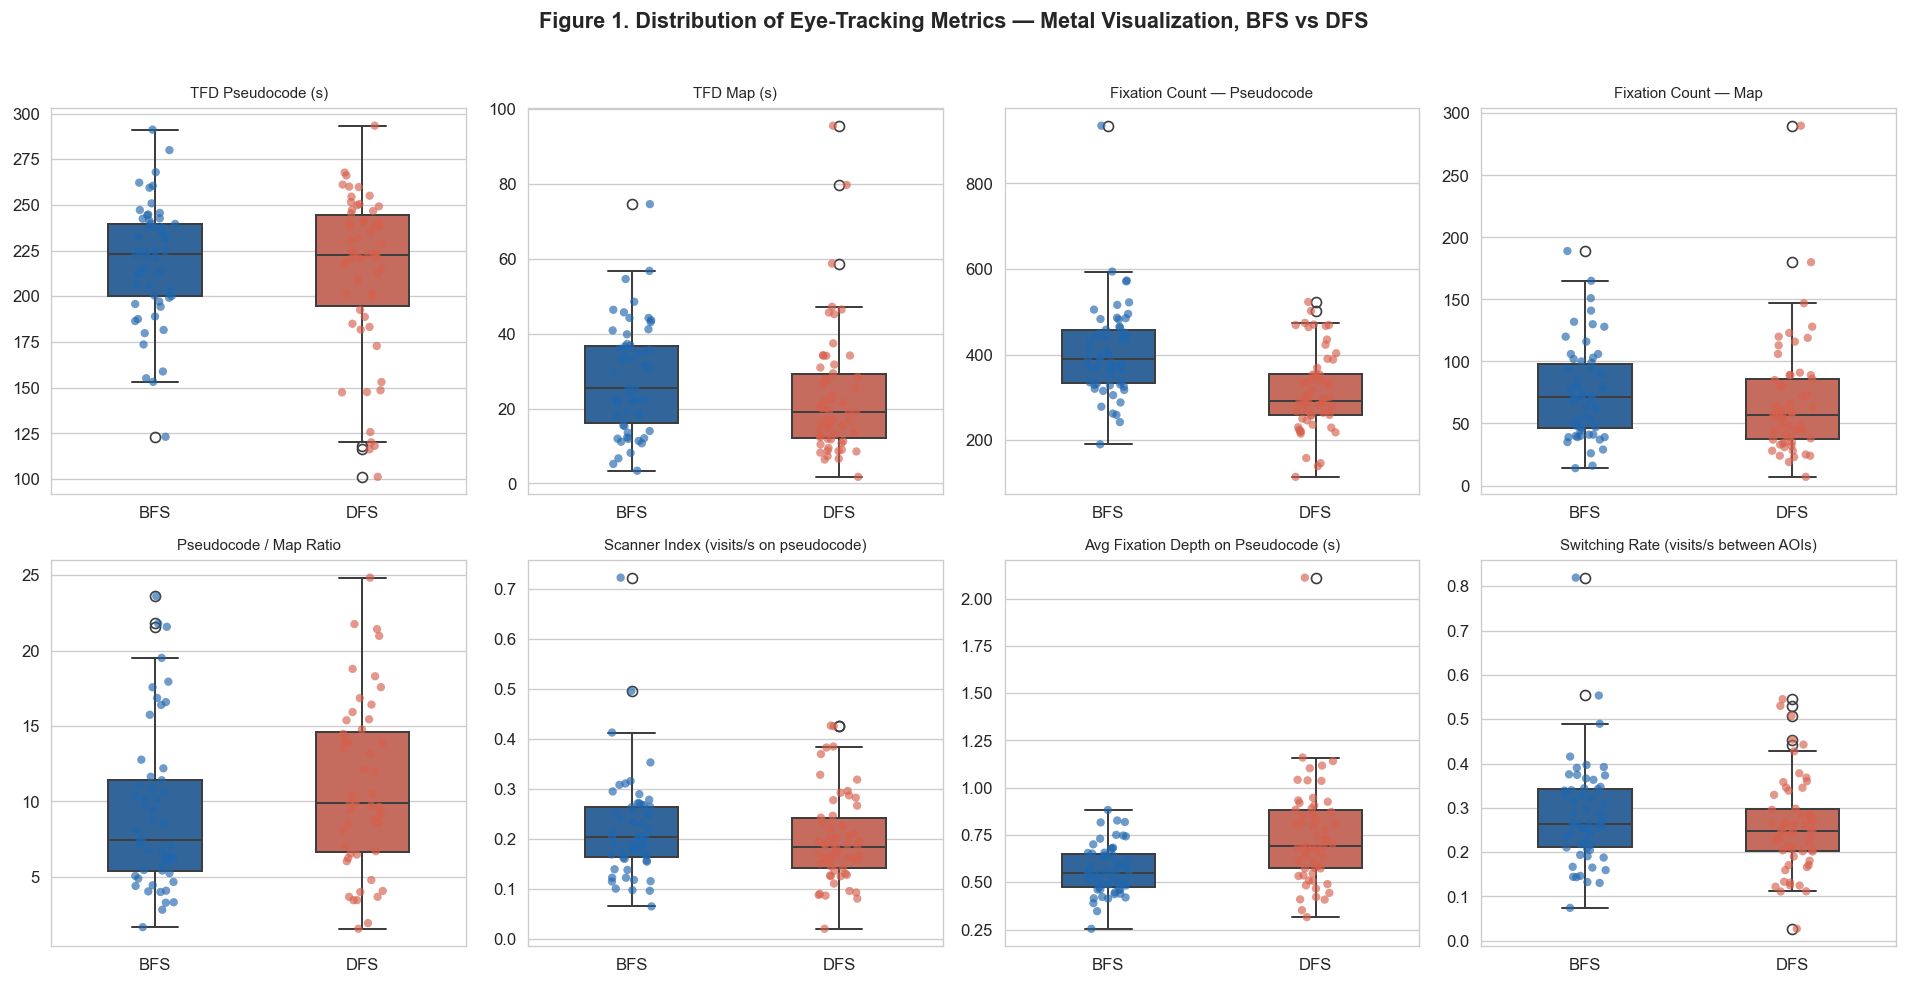

In [4]:
# Figure 1 — Eight-panel overview of key metric distributions
plot_metrics = [
    ('tfd_pseudo',     'TFD Pseudocode (s)'),
    ('tfd_map',        'TFD Map (s)'),
    ('fc_pseudo',      'Fixation Count — Pseudocode'),
    ('fc_map',         'Fixation Count — Map'),
    ('ratio',          'Pseudocode / Map Ratio'),
    ('scanner_index',  'Scanner Index (visits/s on pseudocode)'),
    ('avg_fix_depth',  'Avg Fixation Depth on Pseudocode (s)'),
    ('switching_rate', 'Switching Rate (visits/s between AOIs)'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Figure 1. Distribution of Eye-Tracking Metrics — Metal Visualization, BFS vs DFS',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (col, label) in zip(axes.flat, plot_metrics):
    data = df[df[col].replace([np.inf, -np.inf], np.nan).notna()].copy()
    if col == 'ratio':
        data = data[data[col] < 25]  # clip extreme outliers for display
    sns.boxplot(
        data=data, x='algorithm', y=col, palette=PALETTE,
        order=['BFS', 'DFS'], ax=ax, width=0.45, linewidth=1.2
    )
    sns.stripplot(
        data=data, x='algorithm', y=col, palette=PALETTE,
        order=['BFS', 'DFS'], ax=ax, size=5, alpha=0.65, jitter=True
    )
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('metal_fig1_distributions.png', bbox_inches='tight')
plt.show()

---

## 4. BFS vs DFS — Statistical Comparisons

Mann-Whitney U tests (non-parametric) for all key metrics. Effect size: rank-biserial correlation *r* (small ≥ 0.1, medium ≥ 0.3, large ≥ 0.5).

**Hypotheses:**
- **ratio**: BFS's wave-expansion pattern is harder to visually track → viewers consult pseudocode more → higher ratio for BFS
- **scanner_index**: BFS may produce more brief check-ins (scanning to orient) while DFS produces fewer, longer reads
- **fix_before**: BFS's immediate visual activity may capture the eye before viewers look at code → more pre-pseudocode fixations
- **ttff_pseudo**: If BFS is more visually engaging, first pseudocode fixation comes later
- **switching_rate**: BFS's unpredictable node expansion may cause more rapid alternation between code and map
- **avg_fix_depth**: Longer average fixations on pseudocode in DFS → viewers settle in and read rather than checking

In [5]:
test_metrics = [
    ('ratio',          'Pseudocode/Map Attention Ratio'),
    ('scanner_index',  'Scanner Index (visits/s on pseudocode)'),
    ('avg_fix_depth',  'Avg Fixation Depth on Pseudocode (s)'),
    ('switching_rate', 'Switching Rate'),
    ('fix_before',     'Fixations Before First Pseudocode Look'),
    ('ttff_pseudo',    'Time to First Fixation — Pseudocode (ms)'),
    ('ffd_pseudo',     'First Fixation Duration — Pseudocode (ms)'),
    ('pct_pseudo',     'Percentage Time Fixated on Pseudocode'),
    ('pct_map',        'Percentage Time Fixated on Map'),
]

rows = []
for metric, label in test_metrics:
    b = bfs[metric].replace([np.inf, -np.inf], np.nan).dropna()
    d = dfs[metric].replace([np.inf, -np.inf], np.nan).dropna()
    if len(b) < 2 or len(d) < 2:
        continue
    u, p = stats.mannwhitneyu(b, d, alternative='two-sided')
    r = 1 - (2 * u) / (len(b) * len(d))
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '~' if p < 0.10 else ''
    rows.append({
        'Metric':       label,
        'BFS n':        len(b),
        'BFS median':   round(b.median(), 3),
        'DFS n':        len(d),
        'DFS median':   round(d.median(), 3),
        'U':            u,
        'p':            round(p, 4),
        'r':            round(r, 3),
        'sig':          sig,
    })

results = pd.DataFrame(rows)
print('=== Mann-Whitney U Tests: BFS vs DFS (Metal Only) ===')
print('sig: * p<.05  ** p<.01  *** p<.001  ~ p<.10')
print(results.to_string(index=False))

=== Mann-Whitney U Tests: BFS vs DFS (Metal Only) ===
sig: * p<.05  ** p<.01  *** p<.001  ~ p<.10
                                   Metric  BFS n  BFS median  DFS n  DFS median      U      p      r sig
           Pseudocode/Map Attention Ratio     58       8.343     58      11.200 1374.0 0.0895  0.183   ~
   Scanner Index (visits/s on pseudocode)     58       0.204     58       0.183 1928.0 0.1752 -0.146    
     Avg Fixation Depth on Pseudocode (s)     58       0.547     58       0.693  925.0 0.0000  0.450 ***
                           Switching Rate     58       0.264     58       0.247 1914.0 0.2012 -0.138    
   Fixations Before First Pseudocode Look     58      54.500     58      76.000  366.0 0.0000  0.782 ***
 Time to First Fixation — Pseudocode (ms)     58      18.860     58      25.470   78.0 0.0000  0.954 ***
First Fixation Duration — Pseudocode (ms)     58       0.360     58       0.270 2220.0 0.0030 -0.320  **
    Percentage Time Fixated on Pseudocode     59       1.000  

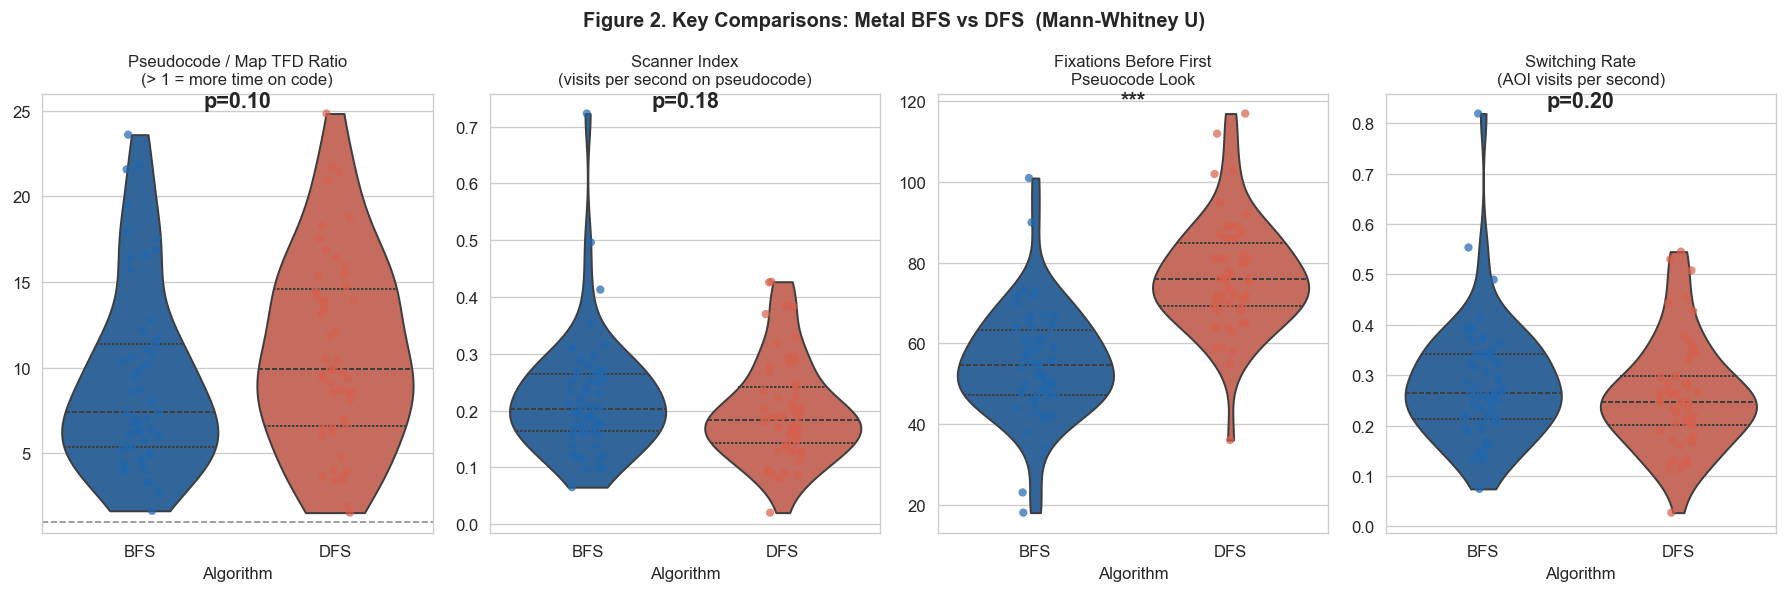

In [6]:
# Figure 2 — Focus plot: four most theoretically interesting comparisons
focus = [
    ('ratio',          'Pseudocode / Map TFD Ratio\n(> 1 = more time on code)',  None),
    ('scanner_index',  'Scanner Index\n(visits per second on pseudocode)',       None),
    ('fix_before',     'Fixations Before First\nPseuocode Look',                 None),
    ('switching_rate', 'Switching Rate\n(AOI visits per second)',                None),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
fig.suptitle(
    'Figure 2. Key Comparisons: Metal BFS vs DFS  (Mann-Whitney U)',
    fontsize=12, fontweight='bold'
)

for ax, (col, label, _) in zip(axes, focus):
    data = df[df[col].replace([np.inf, -np.inf], np.nan).notna()].copy()
    if col == 'ratio':
        data = data[data[col] < 25]

    sns.violinplot(
        data=data, x='algorithm', y=col, palette=PALETTE,
        order=['BFS', 'DFS'], ax=ax, inner='quartile', linewidth=1.2, cut=0
    )
    sns.stripplot(
        data=data, x='algorithm', y=col, palette=PALETTE,
        order=['BFS', 'DFS'], ax=ax, size=5, alpha=0.7, jitter=True
    )

    # Annotate with p-value
    b = data[data['algorithm']=='BFS'][col].dropna()
    d = data[data['algorithm']=='DFS'][col].dropna()
    if len(b) >= 2 and len(d) >= 2:
        _, p = stats.mannwhitneyu(b, d, alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else f'p={p:.2f}'
        ymax = data[col].quantile(0.95)
        ax.annotate(sig, xy=(0.5, 0.97), xycoords='axes fraction',
                    ha='center', fontsize=13, fontweight='bold')

    if col == 'ratio':
        ax.axhline(1.0, color='#444', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Algorithm')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('metal_fig2_key_comparisons.png', bbox_inches='tight')
plt.show()

---

## 5. Within-Algorithm Correlation Analysis

### 5.1 Does Early Map Capture Predict Less Code Reading?

**`fix_before` → `ratio`**: Participants who made many fixations on other AOIs before ever looking at the pseudocode may have been drawn into the map first — and may then have read the code less overall. We test this within each algorithm separately.

**Implication if significant in BFS but not DFS:** BFS's immediate visual activity (wave expansion begins at frame 1) sets an attention trap that compounds over the trial. DFS's simpler early visual state doesn't create the same trap.

In [7]:
def spearman_annotated(x_col, y_col, group, label_x, label_y):
    x = group[x_col].replace([np.inf, -np.inf], np.nan)
    y = group[y_col].replace([np.inf, -np.inf], np.nan)
    valid = x.notna() & y.notna()
    if valid.sum() < 3:
        print(f'  Insufficient valid pairs (n={valid.sum()})')
        return None, None, None
    r, p = stats.spearmanr(x[valid], y[valid])
    n = valid.sum()
    print(f'  Spearman r = {r:.3f},  p = {p:.4f},  n = {n}')
    return r, p, n

print('=== Fixations Before First Pseudocode Look → Pseudocode/Map Ratio ===')
print('  BFS:')
r_bfs, p_bfs, n_bfs = spearman_annotated('fix_before', 'ratio', bfs, 'fix_before', 'ratio')
print('  DFS:')
r_dfs, p_dfs, n_dfs = spearman_annotated('fix_before', 'ratio', dfs, 'fix_before', 'ratio')

=== Fixations Before First Pseudocode Look → Pseudocode/Map Ratio ===
  BFS:
  Spearman r = 0.141,  p = 0.2905,  n = 58
  DFS:
  Spearman r = -0.297,  p = 0.0234,  n = 58


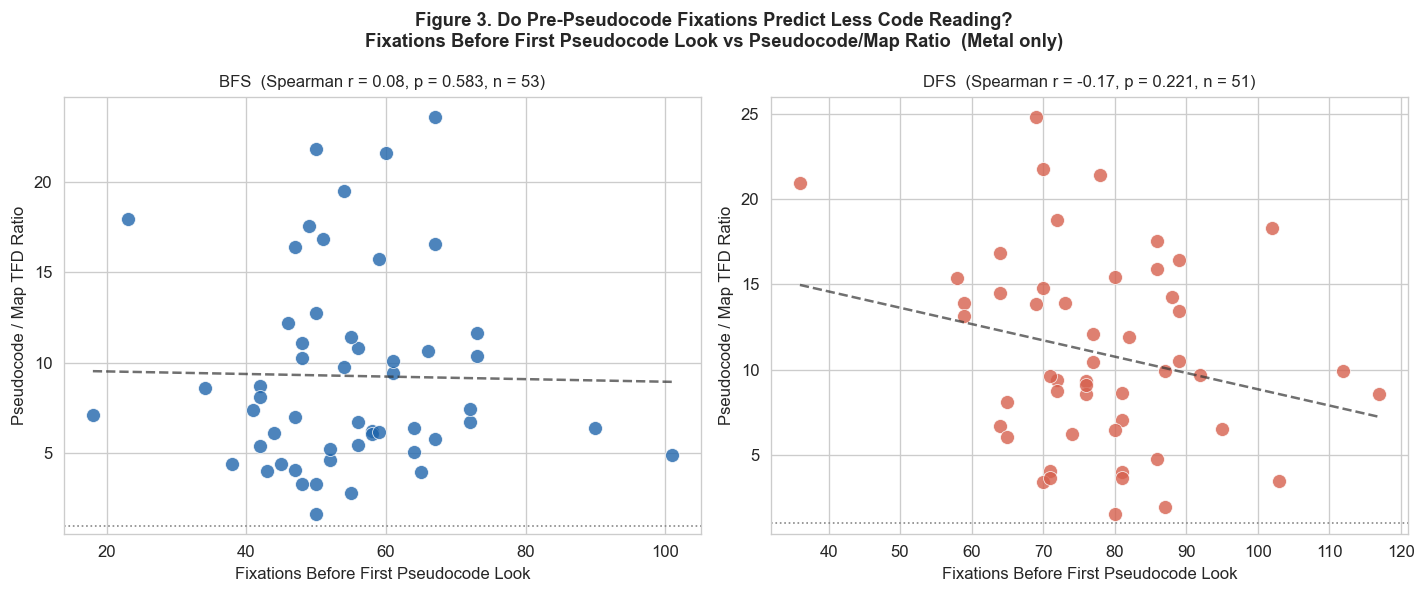

In [8]:
# Figure 3 — Scatter: fix_before vs ratio, BFS and DFS side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'Figure 3. Do Pre-Pseudocode Fixations Predict Less Code Reading?\n'
    'Fixations Before First Pseudocode Look vs Pseudocode/Map Ratio  (Metal only)',
    fontsize=11, fontweight='bold'
)

for ax, (subset, algo) in zip(axes, [(bfs, 'BFS'), (dfs, 'DFS')]):
    x = subset['fix_before'].replace([np.inf, -np.inf], np.nan)
    y = subset['ratio'].replace([np.inf, -np.inf], np.nan)
    valid = x.notna() & y.notna() & (y < 25)
    xv, yv = x[valid], y[valid]

    ax.scatter(xv, yv, color=PALETTE[algo], s=70, alpha=0.8, edgecolors='white', linewidth=0.5)

    if len(xv) >= 3:
        m, b_ = np.polyfit(xv, yv, 1)
        xline = np.linspace(xv.min(), xv.max(), 100)
        ax.plot(xline, m * xline + b_, color='#333', linewidth=1.5, linestyle='--', alpha=0.7)
        r, p = stats.spearmanr(xv, yv)
        ax.set_title(f'{algo}  (Spearman r = {r:.2f}, p = {p:.3f}, n = {len(xv)})', fontsize=10)

    ax.axhline(1.0, color='#888', linestyle=':', linewidth=1)
    ax.set_xlabel('Fixations Before First Pseudocode Look', fontsize=10)
    ax.set_ylabel('Pseudocode / Map TFD Ratio', fontsize=10)

plt.tight_layout()
plt.savefig('metal_fig3_fix_before_ratio.png', bbox_inches='tight')
plt.show()

### 5.2 Does First Contact Duration Predict Total Code Engagement?

**`ffd_pseudo` → `tfd_pseudo`**: If the very first fixation on the pseudocode is long, does that predict greater total fixation time on pseudocode?

**Interpretation:** A long first fixation could mean the viewer was actively reading from the moment they arrived. If this predicts higher total engagement, it suggests that the *quality* of first contact matters — and that visualization designs which interrupt that first fixation (e.g., sudden animation) may cause cumulative underengagement with code.

In [9]:
print('=== First Fixation Duration on Pseudocode → Total Fixation Duration on Pseudocode ===')
print('  BFS:')
r_bfs2, p_bfs2, n_bfs2 = spearman_annotated('ffd_pseudo', 'tfd_pseudo', bfs, 'ffd_pseudo', 'tfd_pseudo')
print('  DFS:')
r_dfs2, p_dfs2, n_dfs2 = spearman_annotated('ffd_pseudo', 'tfd_pseudo', dfs, 'ffd_pseudo', 'tfd_pseudo')

=== First Fixation Duration on Pseudocode → Total Fixation Duration on Pseudocode ===
  BFS:
  Spearman r = 0.112,  p = 0.4043,  n = 58
  DFS:
  Spearman r = 0.063,  p = 0.6394,  n = 58


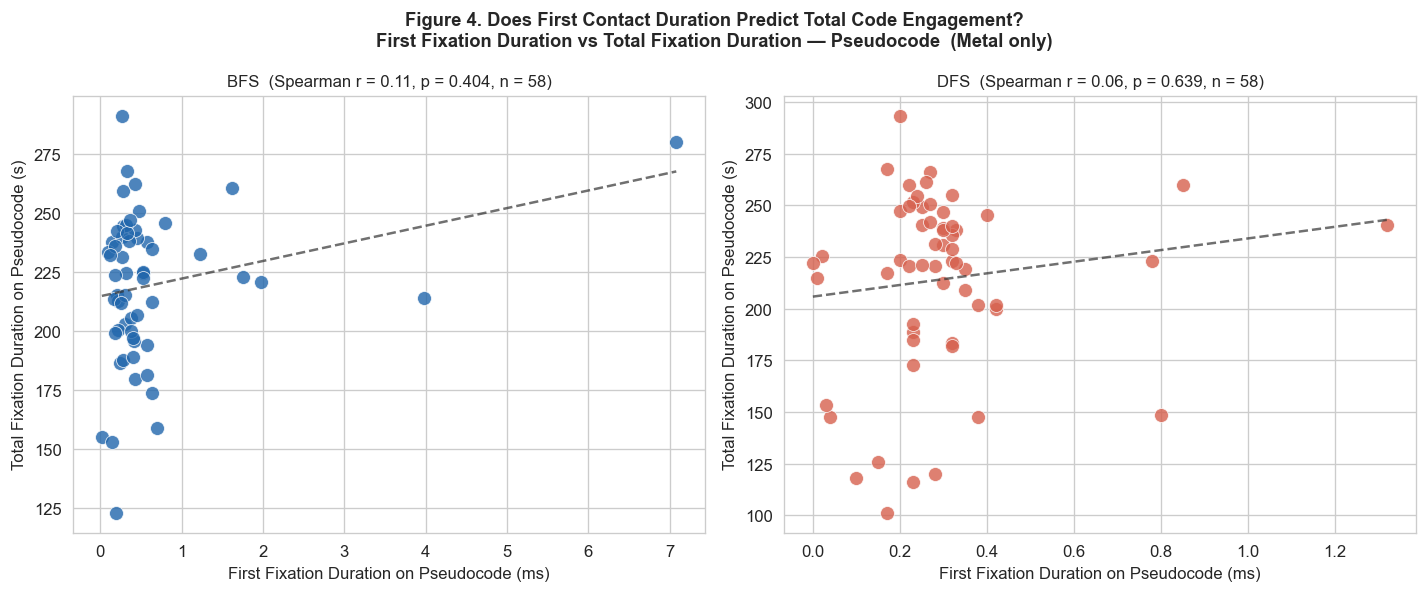

In [10]:
# Figure 4
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'Figure 4. Does First Contact Duration Predict Total Code Engagement?\n'
    'First Fixation Duration vs Total Fixation Duration — Pseudocode  (Metal only)',
    fontsize=11, fontweight='bold'
)

for ax, (subset, algo) in zip(axes, [(bfs, 'BFS'), (dfs, 'DFS')]):
    x = subset['ffd_pseudo'].replace([np.inf, -np.inf], np.nan)
    y = subset['tfd_pseudo'].replace([np.inf, -np.inf], np.nan)
    valid = x.notna() & y.notna()
    xv, yv = x[valid], y[valid]

    ax.scatter(xv, yv, color=PALETTE[algo], s=70, alpha=0.8, edgecolors='white', linewidth=0.5)

    if len(xv) >= 3:
        m, b_ = np.polyfit(xv, yv, 1)
        xline = np.linspace(xv.min(), xv.max(), 100)
        ax.plot(xline, m * xline + b_, color='#333', linewidth=1.5, linestyle='--', alpha=0.7)
        r, p = stats.spearmanr(xv, yv)
        ax.set_title(f'{algo}  (Spearman r = {r:.2f}, p = {p:.3f}, n = {len(xv)})', fontsize=10)

    ax.set_xlabel('First Fixation Duration on Pseudocode (ms)', fontsize=10)
    ax.set_ylabel('Total Fixation Duration on Pseudocode (s)', fontsize=10)

plt.tight_layout()
plt.savefig('metal_fig4_ffd_vs_tfd.png', bbox_inches='tight')
plt.show()

### 5.3 Does Higher Switching Rate Predict Lower or Higher Code Engagement?

**`switching_rate` → `ratio`**: More switches between code and map per unit time could mean either:
- **Active integration** (viewer shuttles between representations → higher ratio) or  
- **Distraction-driven fragmentation** (viewer can't settle → lower ratio, lower avg_fix_depth)

Testing within BFS vs DFS tells us whether the relationship changes depending on how predictable the animation is.

In [11]:
print('=== Switching Rate → Pseudocode/Map Ratio ===')
print('  BFS:')
spearman_annotated('switching_rate', 'ratio', bfs[bfs['ratio'] < 25], 'switching_rate', 'ratio')
print('  DFS:')
spearman_annotated('switching_rate', 'ratio', dfs[dfs['ratio'] < 25], 'switching_rate', 'ratio')

print()
print('=== Switching Rate → Avg Fixation Depth (pseudocode) ===')
print('  BFS:')
spearman_annotated('switching_rate', 'avg_fix_depth', bfs, 'switching_rate', 'avg_fix_depth')
print('  DFS:')
spearman_annotated('switching_rate', 'avg_fix_depth', dfs, 'switching_rate', 'avg_fix_depth')

=== Switching Rate → Pseudocode/Map Ratio ===
  BFS:
  Spearman r = -0.482,  p = 0.0003,  n = 53
  DFS:
  Spearman r = -0.448,  p = 0.0010,  n = 51

=== Switching Rate → Avg Fixation Depth (pseudocode) ===
  BFS:
  Spearman r = -0.506,  p = 0.0001,  n = 58
  DFS:
  Spearman r = -0.532,  p = 0.0000,  n = 58


(-0.5315758712971793, 1.7570735389194682e-05, 58)

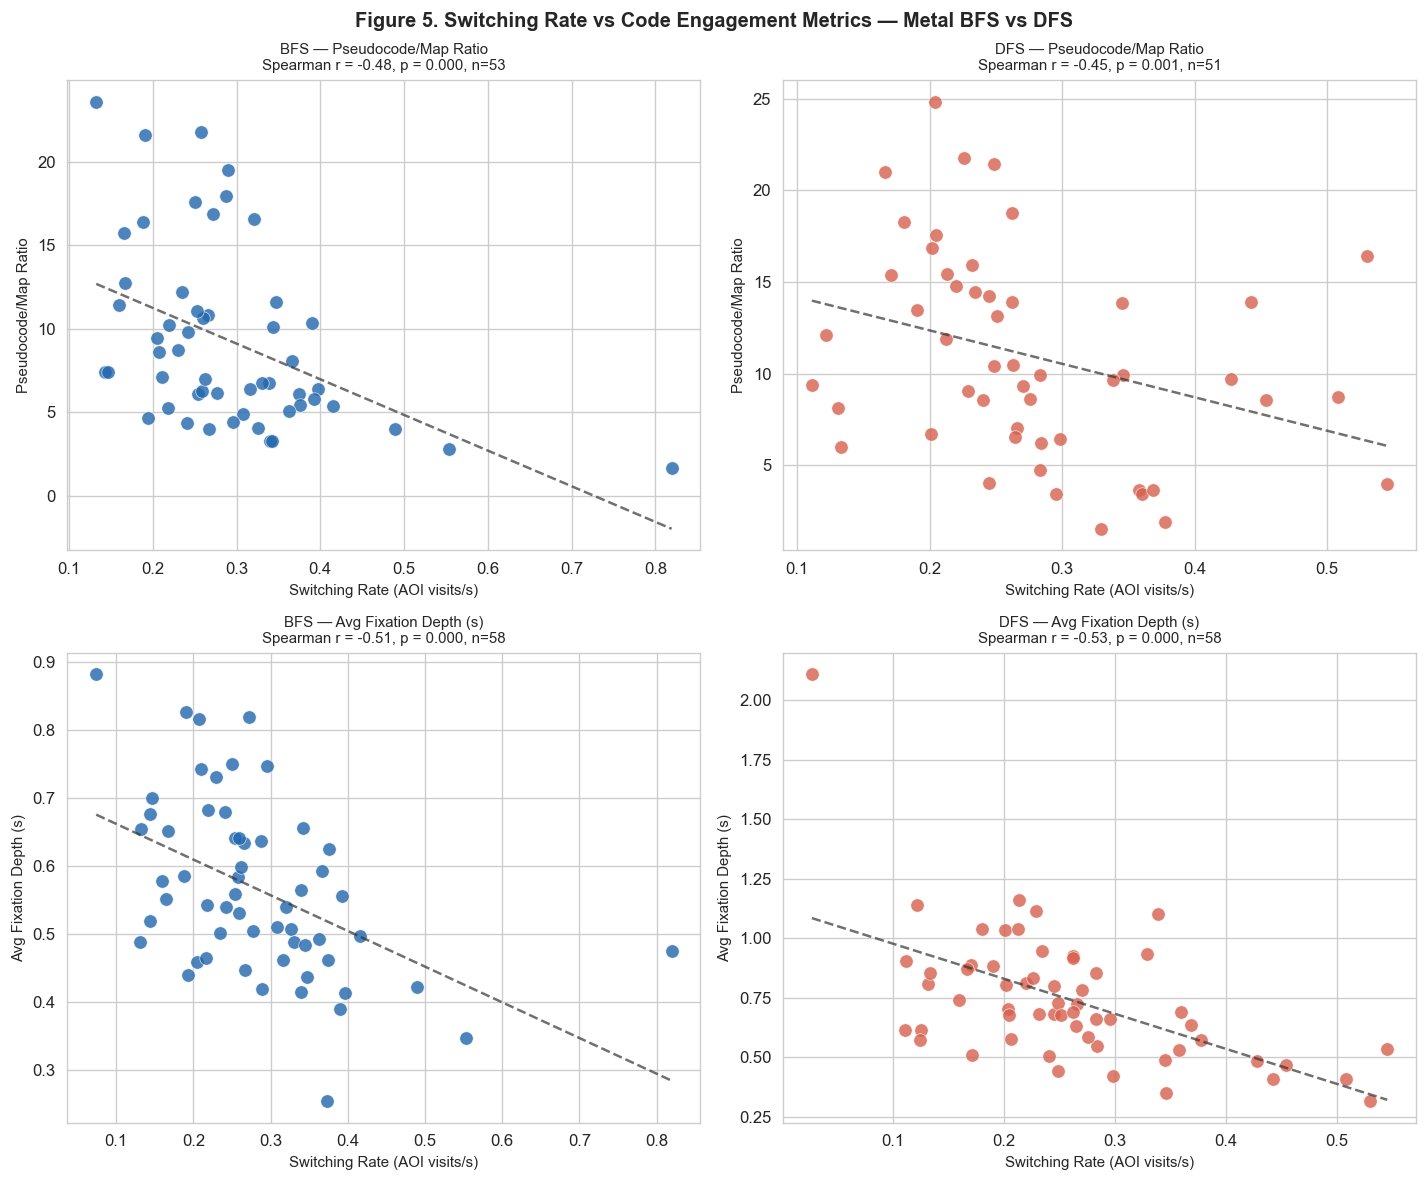

In [12]:
# Figure 5 — 2x2: switching_rate vs ratio (top) and switching_rate vs avg_fix_depth (bottom)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(
    'Figure 5. Switching Rate vs Code Engagement Metrics — Metal BFS vs DFS',
    fontsize=12, fontweight='bold'
)

pairs = [
    (axes[0][0], bfs, 'BFS', 'switching_rate', 'ratio',         'Pseudocode/Map Ratio'),
    (axes[0][1], dfs, 'DFS', 'switching_rate', 'ratio',         'Pseudocode/Map Ratio'),
    (axes[1][0], bfs, 'BFS', 'switching_rate', 'avg_fix_depth', 'Avg Fixation Depth (s)'),
    (axes[1][1], dfs, 'DFS', 'switching_rate', 'avg_fix_depth', 'Avg Fixation Depth (s)'),
]

for ax, subset, algo, xcol, ycol, ylabel in pairs:
    x = subset[xcol].replace([np.inf, -np.inf], np.nan)
    y = subset[ycol].replace([np.inf, -np.inf], np.nan)
    if ycol == 'ratio':
        y = y.where(y < 25)
    valid = x.notna() & y.notna()
    xv, yv = x[valid], y[valid]

    ax.scatter(xv, yv, color=PALETTE[algo], s=65, alpha=0.8, edgecolors='white', linewidth=0.4)
    if len(xv) >= 3:
        m, b_ = np.polyfit(xv, yv, 1)
        xline = np.linspace(xv.min(), xv.max(), 100)
        ax.plot(xline, m * xline + b_, color='#333', linewidth=1.5, linestyle='--', alpha=0.7)
        r, p = stats.spearmanr(xv, yv)
        ax.set_title(f'{algo} — {ylabel}\nSpearman r = {r:.2f}, p = {p:.3f}, n={len(xv)}', fontsize=9)
    ax.set_xlabel('Switching Rate (AOI visits/s)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)

plt.tight_layout()
plt.savefig('metal_fig5_switching_correlations.png', bbox_inches='tight')
plt.show()

---

## 6. Within-Person Stability: Is Attention Allocation a Trait or Task-Driven?

If the same participant watched both BFS and DFS (Metal style), we can test whether their pseudocode/map ratio is consistent across the two algorithms.

- **High Spearman r**: ratio is a stable individual trait — some people are always code-readers, others are always map-watchers, regardless of algorithm. Curriculum intervention (not animation redesign) would be the fix.
- **Low or negative r**: ratio is algorithm-driven — the same person reads code heavily for one algorithm but not the other. Animation redesign matters more than learner traits.

This is the most diagnostic question in the dataset for design implications.

In [13]:
# Match participants who appear in both BFS and DFS Metal files
# Normalize participant IDs before merging
bfs_ids = bfs[['participant', 'ratio', 'scanner_index', 'avg_fix_depth', 'switching_rate']].copy()
dfs_ids = dfs[['participant', 'ratio', 'scanner_index', 'avg_fix_depth', 'switching_rate']].copy()

bfs_ids.columns = ['participant', 'bfs_ratio', 'bfs_scanner', 'bfs_depth', 'bfs_switching']
dfs_ids.columns = ['participant', 'dfs_ratio', 'dfs_scanner', 'dfs_depth', 'dfs_switching']

paired = pd.merge(bfs_ids, dfs_ids, on='participant')
paired = paired.replace([np.inf, -np.inf], np.nan)

print(f'Participants matched across BFS and DFS: n={len(paired)}')
print(paired[['participant', 'bfs_ratio', 'dfs_ratio']].to_string(index=False))

Participants matched across BFS and DFS: n=52
participant  bfs_ratio  dfs_ratio
         P4   4.068326  14.765879
        P10  10.638988   7.026180
        P13   9.446304   9.912752
        P15   6.740000  21.423077
        P16   8.599778  13.846226
        P19   6.744867  18.785714
        P22        NaN   9.702828
        P29   5.402712  14.245999
        P32  11.397188   9.407019
        P33   8.719374  10.428857
        P35  70.355030   8.742170
        P37   6.103527  30.126675
        P40  11.093278  13.910631
        P46  19.515867  40.382398
        P49   2.805128  16.414905
        P52   3.984852  28.546392
         P2   6.406119  13.899306
         P7  17.564576   4.053528
        P17  12.760836  14.466969
        P21  55.998077 167.628571
        P23  17.938861  24.839662
        P25  21.796452   6.231153
        P26   4.648938  15.374682
        P30  10.363636   8.543114
        P44   6.388794   6.466901
        P45  21.578293  15.443520
        P48   8.085310   8.611266
  

In [14]:
wp_tests = [
    ('bfs_ratio',     'dfs_ratio',     'Pseudocode/Map Ratio'),
    ('bfs_scanner',   'dfs_scanner',   'Scanner Index'),
    ('bfs_depth',     'dfs_depth',     'Avg Fixation Depth on Pseudocode'),
    ('bfs_switching', 'dfs_switching', 'Switching Rate'),
]

print('=== Within-Person Spearman Correlations: BFS vs DFS Metrics (same participants) ===')
for xcol, ycol, label in wp_tests:
    sub = paired[[xcol, ycol]].dropna()
    if len(sub) < 3:
        print(f'  {label}: n={len(sub)} — insufficient')
        continue
    r, p = stats.spearmanr(sub[xcol], sub[ycol])
    print(f'  {label}: r = {r:.3f}, p = {p:.4f}, n = {len(sub)}')

=== Within-Person Spearman Correlations: BFS vs DFS Metrics (same participants) ===
  Pseudocode/Map Ratio: r = 0.155, p = 0.2767, n = 51
  Scanner Index: r = 0.589, p = 0.0000, n = 51
  Avg Fixation Depth on Pseudocode: r = 0.627, p = 0.0000, n = 51
  Switching Rate: r = 0.569, p = 0.0000, n = 51


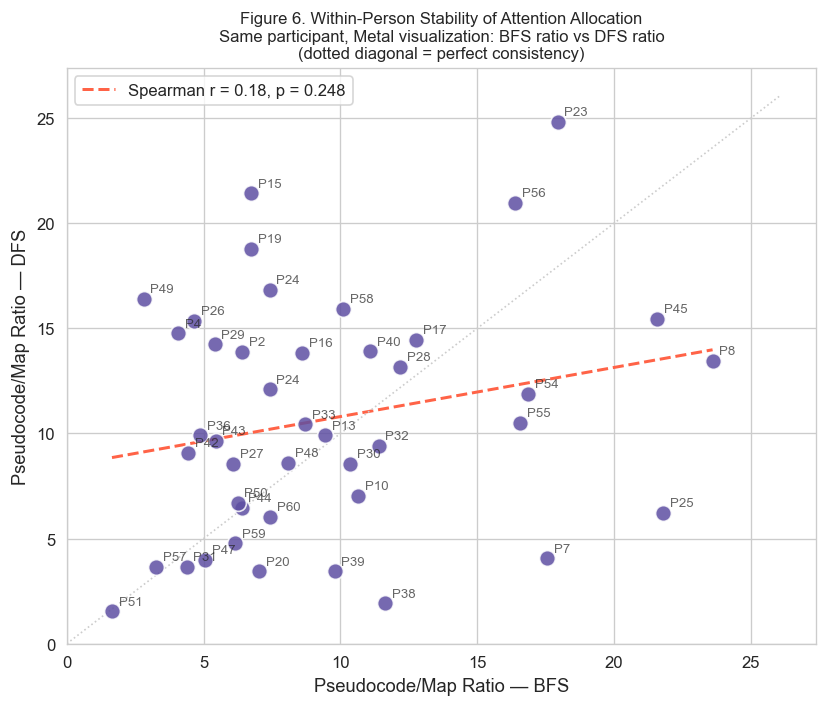

In [15]:
# Figure 6 — Within-person scatter: BFS ratio vs DFS ratio
sub = paired[['participant', 'bfs_ratio', 'dfs_ratio']].dropna()
sub = sub[(sub['bfs_ratio'] < 25) & (sub['dfs_ratio'] < 25)]  # clip extreme outliers

if len(sub) >= 3:
    fig, ax = plt.subplots(figsize=(7, 6))
    r, p = stats.spearmanr(sub['bfs_ratio'], sub['dfs_ratio'])

    ax.scatter(sub['bfs_ratio'], sub['dfs_ratio'],
               color='#5E4FA2', s=90, alpha=0.85, edgecolors='white', zorder=3)

    # Annotate with participant IDs
    for _, row in sub.iterrows():
        ax.annotate(row['participant'],
                    (row['bfs_ratio'], row['dfs_ratio']),
                    fontsize=8, alpha=0.7,
                    xytext=(4, 4), textcoords='offset points')

    # Trendline
    m, b_ = np.polyfit(sub['bfs_ratio'], sub['dfs_ratio'], 1)
    xline = np.linspace(sub['bfs_ratio'].min(), sub['bfs_ratio'].max(), 100)
    ax.plot(xline, m * xline + b_, color='tomato', linewidth=1.8, linestyle='--',
            label=f'Spearman r = {r:.2f}, p = {p:.3f}')

    # Diagonal reference (perfect consistency)
    lim = max(sub['bfs_ratio'].max(), sub['dfs_ratio'].max()) * 1.05
    ax.plot([0, lim], [0, lim], color='#ccc', linewidth=1, linestyle=':')

    ax.set_xlabel('Pseudocode/Map Ratio — BFS', fontsize=11)
    ax.set_ylabel('Pseudocode/Map Ratio — DFS', fontsize=11)
    ax.set_title(
        'Figure 6. Within-Person Stability of Attention Allocation\n'
        'Same participant, Metal visualization: BFS ratio vs DFS ratio\n'
        '(dotted diagonal = perfect consistency)',
        fontsize=10
    )
    ax.legend(fontsize=10)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.savefig('metal_fig6_within_person.png', bbox_inches='tight')
    plt.show()
else:
    print(f'Figure 6 skipped: only {len(sub)} matched participants with valid data.')

---

## 7. Full Correlation Matrix — Metal Only

Spearman correlation across all derived metrics, computed separately for BFS and DFS. Side-by-side heatmaps surface relationships that differ between algorithms.

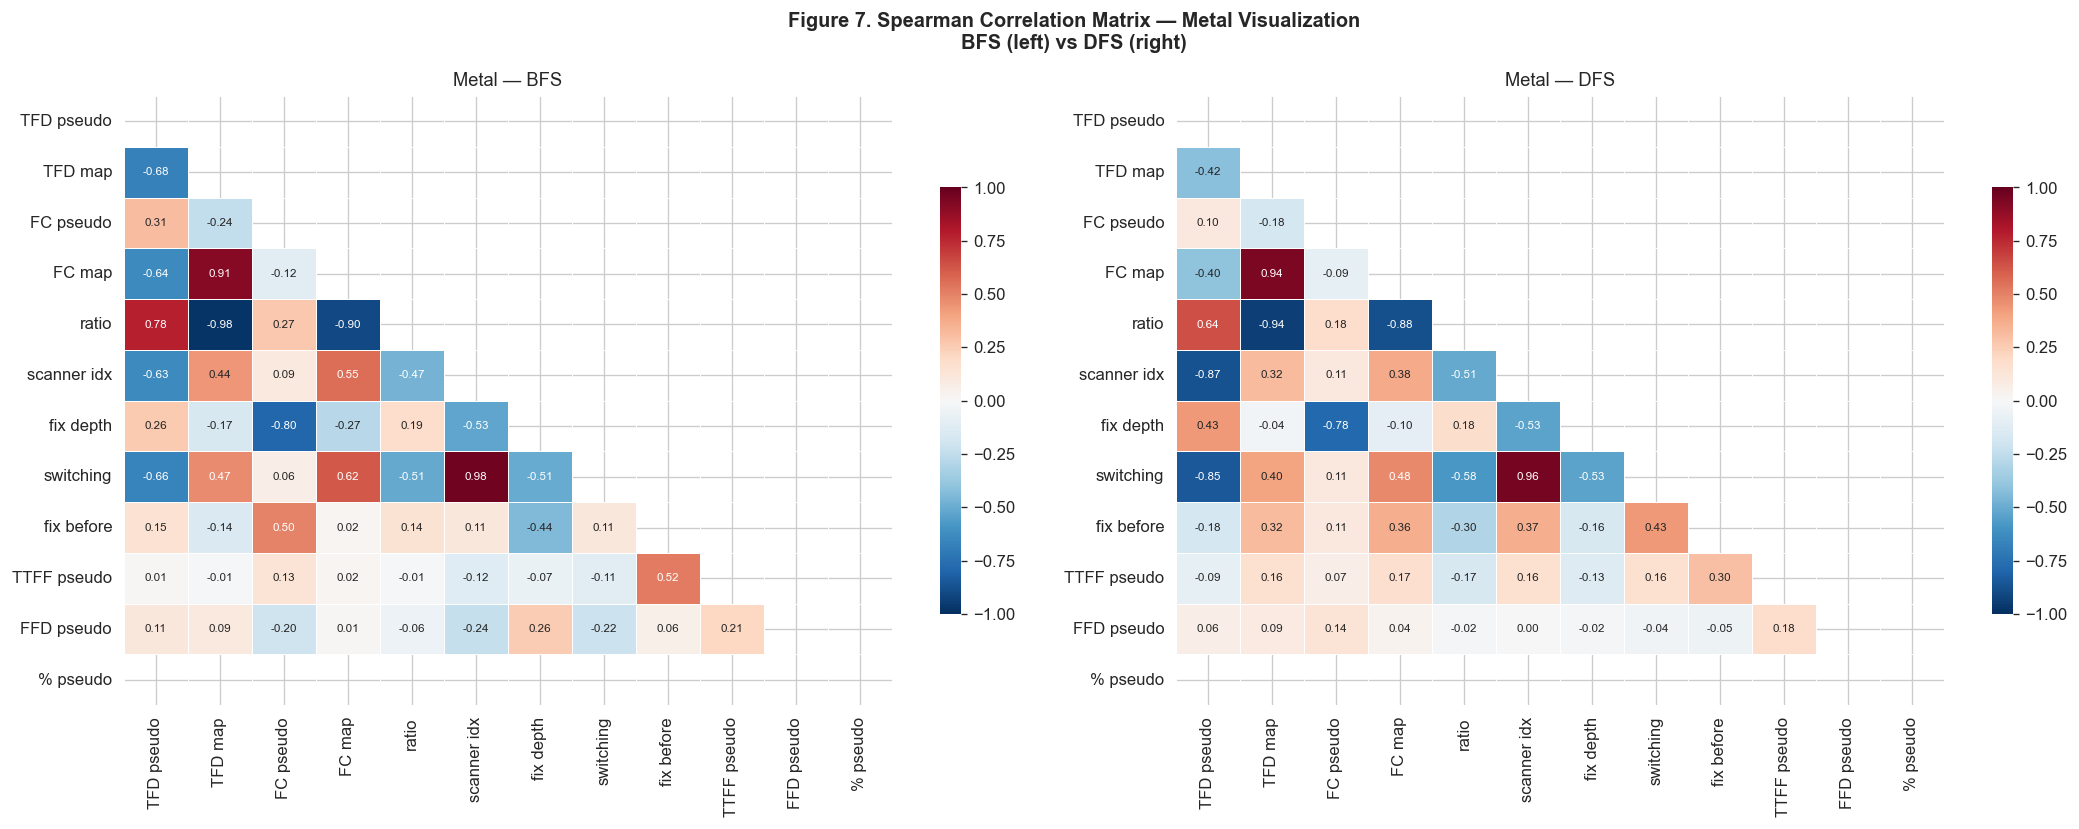

In [16]:
corr_cols = [
    'tfd_pseudo', 'tfd_map', 'fc_pseudo', 'fc_map',
    'ratio', 'scanner_index', 'avg_fix_depth', 'switching_rate',
    'fix_before', 'ttff_pseudo', 'ffd_pseudo', 'pct_pseudo'
]
corr_labels = [
    'TFD pseudo', 'TFD map', 'FC pseudo', 'FC map',
    'ratio', 'scanner idx', 'fix depth', 'switching',
    'fix before', 'TTFF pseudo', 'FFD pseudo', '% pseudo'
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Figure 7. Spearman Correlation Matrix — Metal Visualization\n'
    'BFS (left) vs DFS (right)',
    fontsize=12, fontweight='bold'
)

for ax, (subset, algo) in zip(axes, [(bfs, 'BFS'), (dfs, 'DFS')]):
    mat = (
        subset[corr_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .corr(method='spearman')
    )
    mat.index = corr_labels
    mat.columns = corr_labels
    mask = np.triu(np.ones_like(mat, dtype=bool))
    sns.heatmap(
        mat, mask=mask, annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.7},
        annot_kws={'size': 7}
    )
    ax.set_title(f'Metal — {algo}', fontsize=11)

plt.tight_layout()
plt.savefig('metal_fig7_corr_matrix.png', bbox_inches='tight')
plt.show()

---

## 8. Interpretation Guide

### Pseudocode/Map Ratio — BFS vs DFS

**If BFS ratio > DFS ratio (significant):** BFS's wave-expansion traversal is harder to visually predict. Viewers cannot simply track a moving frontier — the next wave of nodes activates in all directions simultaneously. This forces them to consult the pseudocode to determine which node is "current." DFS's depth-first path, by contrast, follows a visible thread through the graph; viewers can watch it without reading the code at each step.

**Design implication:** BFS animations need stronger pseudocode scaffolding (highlighted active line, synchronized annotation) not in spite of their visual complexity but *because* the viewer is already looking at the code more — the code needs to pay off that attention.

---

### Scanner Index — BFS vs DFS

**If BFS scanner index > DFS scanner index:** BFS produces many brief code check-ins rather than sustained reading. This is consistent with a "verification loop" pattern: watch the graph, get confused, glance at the code, look back. DFS produces fewer, longer code reads — suggesting viewers settle in and read sequentially rather than sampling.

**Design implication:** For BFS, the pseudocode panel should support rapid scanning (highlighted active line, minimal prose). For DFS, it can support deeper reading (more explanatory commentary per line).

---

### Fix Before → Ratio Correlation

**If significant and negative (more pre-pseudocode fixations → lower ratio):** The first few seconds of the animation determine whether a viewer ends up as a code-reader or a map-watcher. Once the map captures attention, the viewer stays there.

**If stronger in BFS than DFS:** BFS's first frame is more visually active (multiple edges already highlighted), creating a stronger initial attentional pull toward the map. DFS starts with a single node activation — less visually arresting.

**Design implication:** The decisive intervention window is the first 2–3 seconds. Delaying map animation by a brief interval or forcing pseudocode contact first could permanently shift attention allocation for the full trial.

---

### First Fixation Duration → Total Engagement

**If significant:** The quality of first contact with pseudocode matters. A viewer who dwells on the code at first contact is likely reading, not just sampling — and that reading posture carries through the trial.

**Design implication:** Anything that interrupts the first fixation on pseudocode (a sudden animation in peripheral vision, a high-contrast color change on the map) could permanently reduce code engagement. Designs should minimize visual events in the early frames of the trial.

---

### Switching Rate Correlation

**If switching rate positively correlates with ratio:** High switchers are active integrators — they are actively cross-referencing code and graph, and the ratio stays high because pseudocode is part of that loop. This is good engagement.

**If switching rate negatively correlates with avg_fix_depth:** High switchers have shorter fixations — they are fragmented rather than integrating. The switching reflects distraction, not comprehension strategy.

The sign and pattern across BFS vs DFS would tell you whether switching is healthy (integrative) in one algorithm but fragmented in the other.

---

### Within-Person Stability (Figure 6)

**High Spearman r (r > 0.5):** Attention allocation is a learner trait. Some people are code-readers regardless of algorithm; others are map-watchers regardless. The right intervention is curriculum-level (pre-training on algorithm pseudocode literacy), not animation redesign.

**Low or near-zero r:** The algorithm — not the person — drives attention. The same participant becomes a code-reader for one algorithm and a map-watcher for another. This means animation redesign is the right lever: specific algorithms need specific attention-directing techniques.

**Negative r:** A subset of participants switches roles across algorithms (heavy code-reader for BFS, heavy map-watcher for DFS, or vice versa). This would be the most surprising and theoretically interesting result — it would suggest that individual compensation strategies vary by algorithm difficulty.

---

## 9. Limitations

1. **AOI naming.** Rectangle = Pseudocode and Rectangle 2 = Map is inferred from the study layout; verify against the Tobii Studio project.
2. **Small N.** Approximately 7–10 participants per algorithm condition. Only large effects are reliably detectable; treat p-values as directional rather than confirmatory.
3. **No comprehension outcome.** Fixation patterns are proxies for engagement, not learning.
4. **No trial order control.** If BFS was always shown before DFS, within-person comparisons conflate algorithm effects with practice effects.
5. **Metal only.** All findings are conditioned on the Metal visualization style. Whether the same BFS/DFS differences appear in Galles or IRN is untested here.